# The Maltese Traffic Sign Dataset (MTSD) — Exploratory Data Analysis

**MSc Dissertation · University of Malta**

This notebook presents a systematic exploratory analysis of the Maltese Traffic Sign Dataset
(MTSD), a smartphone-collected image corpus of traffic signs and street furniture captured
across Malta and Gozo. The analysis characterises the dataset along four axes:

1. the **image collection** itself (formats, geometry, file properties);
2. the **acquisition process** (devices, optics, exposure settings, capture conditions);
3. the **spatial and temporal footprint** of the collection campaign; and
4. the **QA-verified annotations** (class balance, bounding-box geometry, auxiliary
   attributes, and annotation quality).

Each figure is exported at 300 dpi to `Documents/MTSD-EDA/Figures/` and every summary table
to `Documents/MTSD-EDA/GeneratedCSVs/`, so all artefacts can be referenced directly from the
dissertation text.

### Methodological notes

- **The dataset is analysed as a single corpus.** The `GRP-*` folders exist only because the
  collection was partitioned for distribution to third-party annotators; the partitioning
  carries no analytical meaning and is deliberately ignored throughout (it is retained solely
  as file-system provenance).
- **Only the QA-verified annotation exports** (`QA-GRP*.json`) are used as annotation ground
  truth. Raw annotator outputs are never read.
- **Reproducibility.** All statistics derive from two inputs: a cached image-metadata
  inventory (rebuildable from the raw images with `FORCE_RESCAN = True`) and the QA JSON
  files. Re-running the notebook top-to-bottom regenerates every figure and table.

### Contents

1. [Setup and configuration](#1-Setup-and-configuration)
2. [Data loading and corpus overview](#2-Data-loading-and-corpus-overview)
3. [Image collection characteristics](#3-Image-collection-characteristics)
4. [Acquisition devices and camera settings](#4-Acquisition-devices-and-camera-settings)
5. [Geospatial analysis](#5-Geospatial-analysis)
6. [Temporal analysis](#6-Temporal-analysis)
7. [Annotation analysis](#7-Annotation-analysis)
8. [Dataset summary and discussion](#8-Dataset-summary-and-discussion)
9. [Exported artefacts](#9-Exported-artefacts)


## 1. Setup and configuration

The analysis depends only on the scientific Python stack plus the local `mtsd_eda` support
package (image scanning, COCO loading, geodesic helpers, and the figure style). Library
versions are printed for the record.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

if not any((Path(p) / "mtsd_eda").is_dir() for p in sys.path if p):
    sys.path.insert(0, str(Path.cwd()))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter

from mtsd_eda import coco, config, geo, inventory, plotstyle

plotstyle.apply()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(f"{'Python':<12} {sys.version.split()[0]}")
for module in (np, pd, mpl):
    print(f"{module.__name__:<12} {module.__version__}")
print(f"{'Repository':<12} {config.BASE_DIR}")


Python       3.12.11
numpy        2.0.1
pandas       2.3.3
matplotlib   3.10.6
Repository   E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark


In [2]:
# Reproducibility switches ----------------------------------------------------
# FORCE_RESCAN=True re-reads every image header from disk (~30 s on an SSD);
# when False, the cached inventory CSV is reused if present.
FORCE_RESCAN = False
COMPUTE_HASHES = True        # perceptual hashes are required for duplicate detection
NEAR_DUPLICATE_BITS = 2      # max dHash Hamming distance treated as a near-duplicate

config.ensure_output_dirs()
print(f"Figure output : {config.FIGURES_DIR}")
print(f"CSV output    : {config.CSV_DIR}")


Figure output : E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MTSD-EDA\Figures
CSV output    : E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MTSD-EDA\GeneratedCSVs


## 2. Data loading and corpus overview

Two independent sources are loaded:

- the **image inventory** — one record per file found under `Datasets/MTSD/GRP-*`, with
  dimensions, EXIF camera metadata, GPS coordinates, capture timestamps, and a 64-bit
  perceptual hash; and
- the **QA-verified annotation set** — every `QA-GRP*.json` COCO export merged into a
  single table with globally unique identifiers.

The annotated subset is expected to grow as further QA batches are signed off; all
statistics below are computed from whatever QA files are present at run time.


In [3]:
inv = inventory.build_inventory(force=FORCE_RESCAN, compute_hash=COMPUTE_HASHES)
readable = inv[~inv["is_corrupted"]].copy()

qa_images, qa_anns, qa_cats = coco.load_qa_dataset()
qa_files = coco.discover_qa_files()

print(f"Images on disk      : {len(inv):,}")
print(f"Readable            : {len(readable):,}")
print(f"Unreadable/corrupted: {int(inv['is_corrupted'].sum()):,}")
print(f"QA annotation files : {', '.join(p.name for p in qa_files)}")
print(f"QA-verified images  : {len(qa_images):,}")
print(f"QA annotations      : {len(qa_anns):,}")


Images on disk      : 7,492
Readable            : 7,492
Unreadable/corrupted: 0
QA annotation files : QA-GRP1.json, QA-GRP2.json, QA-GRP3.json
QA-verified images  : 1,971
QA annotations      : 5,457


In [4]:
timestamped = readable.dropna(subset=["datetime_original"])
capture_window = (
    f"{timestamped['datetime_original'].min():%d %b %Y} - "
    f"{timestamped['datetime_original'].max():%d %b %Y}"
) if len(timestamped) else "n/a"

overview = pd.DataFrame(
    [
        ("Images on disk", f"{len(inv):,}"),
        ("Readable images", f"{len(readable):,}"),
        ("Total volume", f"{inv['file_size_bytes'].sum() / 1024**3:,.2f} GiB"),
        ("Images with EXIF metadata", f"{int(readable['has_exif'].sum()):,}"
         f"  ({readable['has_exif'].mean():.1%})"),
        ("Images with GPS coordinates", f"{int(readable['has_gps'].sum()):,}"
         f"  ({readable['has_gps'].mean():.1%})"),
        ("Images with capture timestamp", f"{len(timestamped):,}"
         f"  ({len(timestamped) / len(readable):.1%})"),
        ("Capture window", capture_window),
        ("QA-verified images", f"{len(qa_images):,}"),
        ("QA-verified annotations", f"{len(qa_anns):,}"),
        ("Annotation classes", f"{len(qa_cats)}"),
    ],
    columns=["Metric", "Value"],
)
overview.to_csv(config.CSV_DIR / "dataset_overview.csv", index=False)
overview.style.hide(axis="index")


Metric,Value
Images on disk,"7,492"
Readable images,"7,492"
Total volume,20.76 GiB
Images with EXIF metadata,"5,759 (76.9%)"
Images with GPS coordinates,"4,228 (56.4%)"
Images with capture timestamp,"5,432 (72.5%)"
Capture window,06 Nov 2025 - 31 Jan 2026
QA-verified images,"1,971"
QA-verified annotations,"5,457"
Annotation classes,12


## 3. Image collection characteristics

### 3.1 File formats and sizes

Smartphone cameras write plain JPEG, MPO (a JPEG container with an embedded depth/secondary
frame, produced by several Android devices), or PNG (typically screenshots or edited
exports). MPO files behave exactly like JPEG for all downstream tooling — the primary frame
is a standard JPEG image.


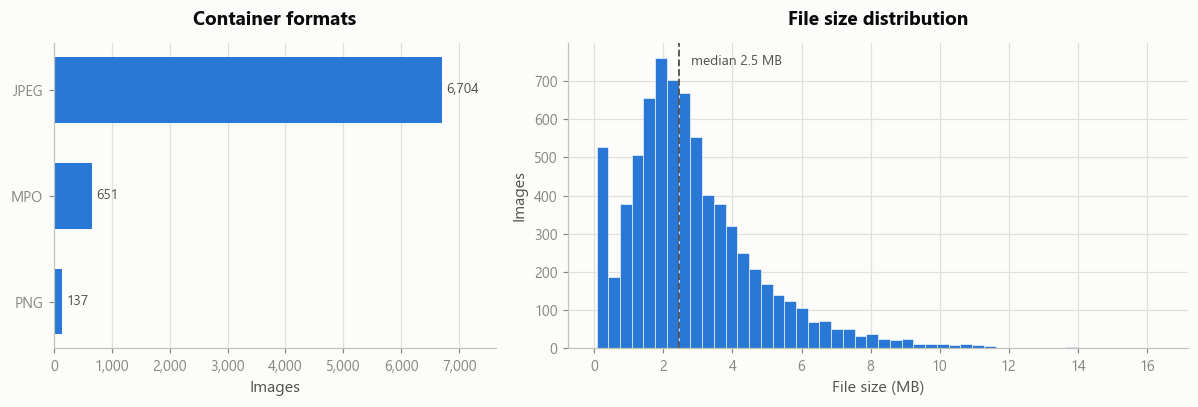

Total volume  : 20.76 GiB
Mean file size: 2.84 MB   median: 2.46 MB   IQR: 1.58-3.69 MB


In [5]:
format_counts = readable["format"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.4]})

bars = axes[0].barh(format_counts.index[::-1], format_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[0], bars)
plotstyle.style_h_barh(axes[0])
axes[0].set_title("Container formats")
axes[0].set_xlabel("Images")
axes[0].xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
axes[0].margins(x=0.14)

sizes = readable["file_size_mb"]
axes[1].hist(sizes, bins=48, color=plotstyle.ACCENT, edgecolor=plotstyle.SURFACE,
             linewidth=0.4)
axes[1].axvline(sizes.median(), color=plotstyle.INK_SECONDARY, linewidth=1.2,
                linestyle="--")
axes[1].annotate(f"median {sizes.median():.1f} MB",
                 xy=(sizes.median(), 1), xycoords=("data", "axes fraction"),
                 xytext=(8, -14), textcoords="offset points",
                 color=plotstyle.INK_SECONDARY, fontsize=9)
axes[1].set_title("File size distribution")
axes[1].set_xlabel("File size (MB)")
axes[1].set_ylabel("Images")
axes[1].yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))

fig.tight_layout()
plotstyle.save_fig(fig, "fig01_formats_and_file_size")
plt.show()

print(f"Total volume  : {readable['file_size_bytes'].sum() / 1024**3:.2f} GiB")
print(f"Mean file size: {sizes.mean():.2f} MB   median: {sizes.median():.2f} MB   "
      f"IQR: {sizes.quantile(0.25):.2f}-{sizes.quantile(0.75):.2f} MB")


### 3.2 Resolution, aspect ratio, and orientation

Pixel dimensions below are **display-corrected**: where the EXIF orientation tag indicates a
90° stored rotation, width and height are swapped so that portrait captures are counted as
portrait. The resolution landscape shows every distinct (width × height) combination in the
corpus; the marker area is proportional to the number of images.


C:\Users\fridge\AppData\Local\Temp\ipykernel_5416\941135542.py:16: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Segoe UI.
  fig.tight_layout()
e:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Scripts\MTSD-Scripts\MTSD-Analysis\mtsd_eda\plotstyle.py:95: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Segoe UI.
  fig.savefig(target)
c:\Users\fridge\anaconda3\envs\MDWD\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)


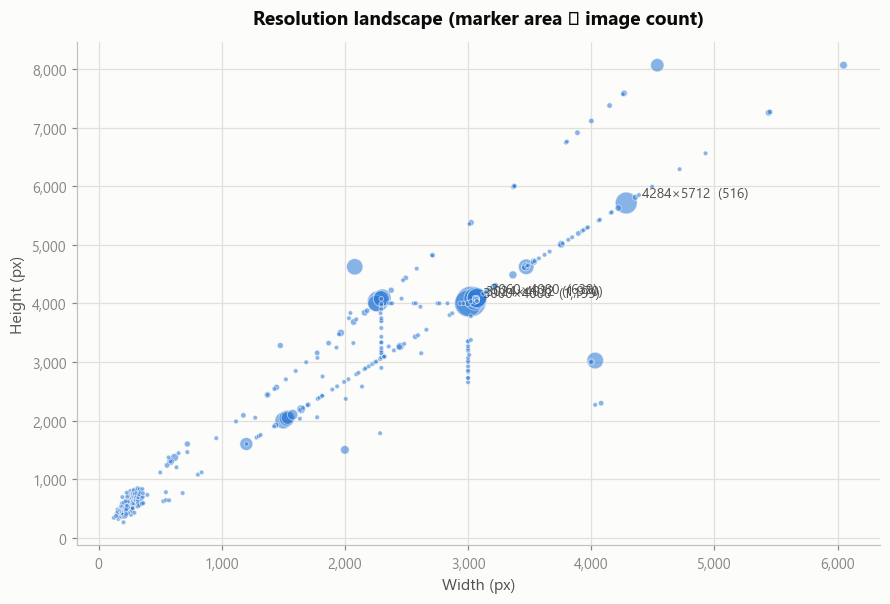

Distinct resolutions: 364
 width  height  count
  3024    4032   1970
  3000    4000   1199
  3060    4080    639
  4284    5712    516
  2268    4032    441
  3072    4080    348
  3072    4096    330
  2304    4096    213


In [6]:
res = (readable.groupby(["width", "height"]).size()
       .reset_index(name="count").sort_values("count", ascending=False))

fig, ax = plt.subplots(figsize=(8.2, 5.6))
ax.scatter(res["width"], res["height"], s=np.sqrt(res["count"]) * 9,
           color=plotstyle.ACCENT, alpha=0.55, edgecolor=plotstyle.SURFACE, linewidth=0.6)
for _, row in res.head(4).iterrows():
    ax.annotate(f"{row['width']:.0f}×{row['height']:.0f}  ({row['count']:,})",
                xy=(row["width"], row["height"]), xytext=(10, 4),
                textcoords="offset points", fontsize=9, color=plotstyle.INK_SECONDARY)
ax.set_title("Resolution landscape (marker area ∝ image count)")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.tight_layout()
plotstyle.save_fig(fig, "fig02_resolution_landscape")
plt.show()

print(f"Distinct resolutions: {len(res)}")
print(res.head(8).to_string(index=False))


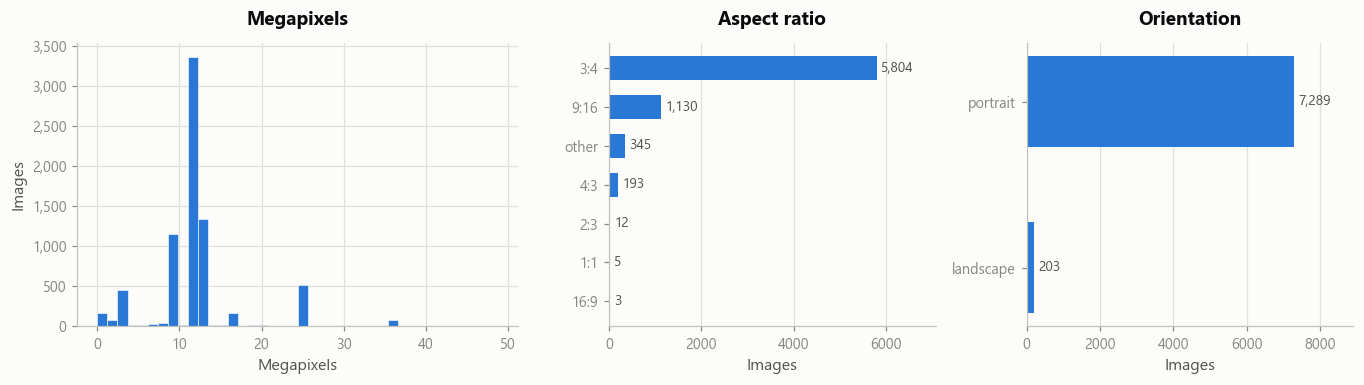

Median resolution : 3024×4032 px
Megapixels        : mean 12.1, median 12.2, range 0.0-48.8
Portrait share    : 97.3%


In [7]:
def nearest_ratio(value: float) -> str:
    named = {"3:4": 3/4, "4:3": 4/3, "9:16": 9/16, "16:9": 16/9,
             "1:1": 1.0, "2:3": 2/3, "3:2": 3/2}
    name, ratio = min(named.items(), key=lambda item: abs(item[1] - value))
    return name if abs(ratio - value) / ratio < 0.05 else "other"

readable["aspect_class"] = readable["aspect_ratio"].map(nearest_ratio)
aspect_counts = readable["aspect_class"].value_counts()
orient_counts = readable["orientation"].value_counts()
mp = readable["megapixels"]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6),
                         gridspec_kw={"width_ratios": [1.35, 1, 1]})

axes[0].hist(mp, bins=40, color=plotstyle.ACCENT, edgecolor=plotstyle.SURFACE,
             linewidth=0.4)
axes[0].set_title("Megapixels")
axes[0].set_xlabel("Megapixels")
axes[0].set_ylabel("Images")
axes[0].yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))

bars = axes[1].barh(aspect_counts.index[::-1], aspect_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[1], bars)
plotstyle.style_h_barh(axes[1])
axes[1].set_title("Aspect ratio")
axes[1].set_xlabel("Images")
axes[1].margins(x=0.22)

bars = axes[2].barh(orient_counts.index[::-1], orient_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.55)
plotstyle.bar_value_labels(axes[2], bars)
plotstyle.style_h_barh(axes[2])
axes[2].set_title("Orientation")
axes[2].set_xlabel("Images")
axes[2].margins(x=0.22)

fig.tight_layout()
plotstyle.save_fig(fig, "fig03_geometry_profile")
plt.show()

print(f"Median resolution : {readable['width'].median():.0f}×{readable['height'].median():.0f} px")
print(f"Megapixels        : mean {mp.mean():.1f}, median {mp.median():.1f}, "
      f"range {mp.min():.1f}-{mp.max():.1f}")
print(f"Portrait share    : {orient_counts.get('portrait', 0) / len(readable):.1%}")


## 4. Acquisition devices and camera settings

EXIF metadata identifies the capturing hardware and exposure parameters. Because the corpus
was gathered by multiple volunteers on personal smartphones, device diversity is a genuine
property of the dataset — it broadens the sensor/optics distribution but also implies
heterogeneous colour rendition and sharpness. Images without EXIF (e.g. exports through
messaging apps that strip metadata) are reported as *unknown*.


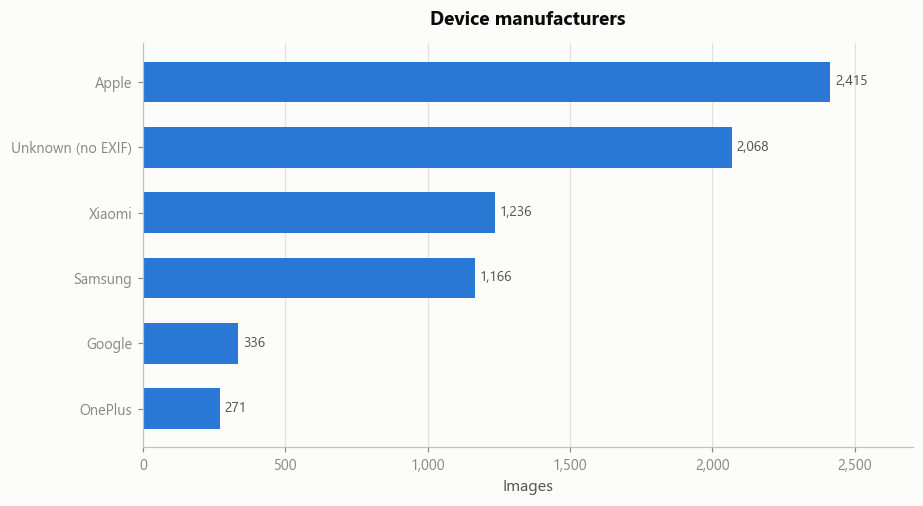

In [8]:
MAKE_ALIASES = {"Samsung": "Samsung", "Oneplus": "OnePlus", "Xiaomi": "Xiaomi"}
readable["make_norm"] = (
    readable["camera_make"].str.strip().str.title().replace(MAKE_ALIASES)
)
make_counts = readable["make_norm"].fillna("Unknown (no EXIF)").value_counts()

fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(make_counts) + 1.4))
bars = ax.barh(make_counts.index[::-1], make_counts.values[::-1],
               color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(ax, bars)
plotstyle.style_h_barh(ax)
ax.set_title("Device manufacturers")
ax.set_xlabel("Images")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.margins(x=0.12)
fig.tight_layout()
plotstyle.save_fig(fig, "fig04_manufacturers")
plt.show()


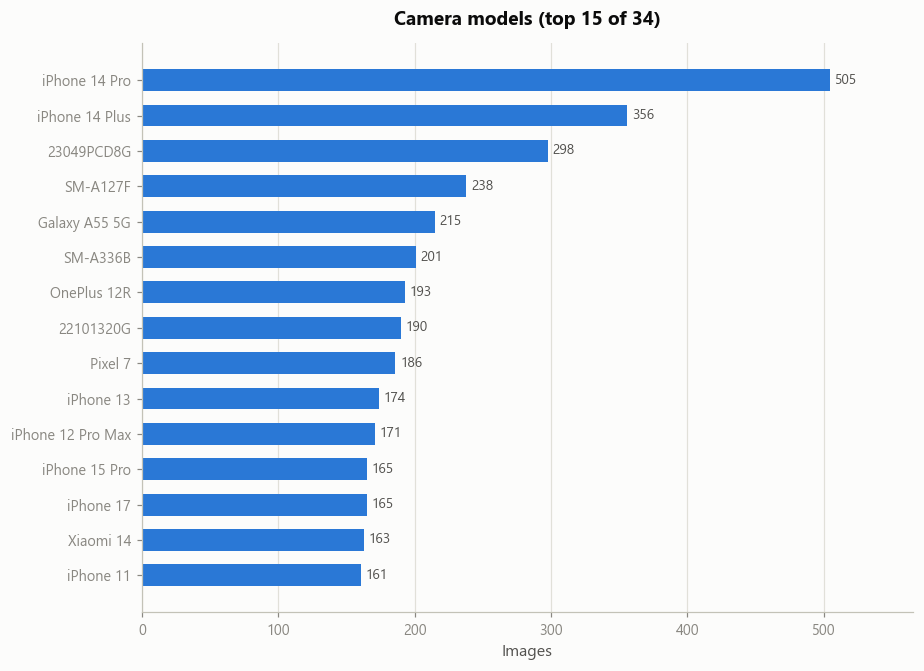

Distinct models: 34  (top model covers 6.7% of the corpus)


In [9]:
model_counts = (readable.dropna(subset=["camera_model"])
                .groupby(["make_norm", "camera_model"]).size()
                .sort_values(ascending=False))
top_models = model_counts.head(15)
labels = [f"{model}" for (_, model) in top_models.index][::-1]

fig, ax = plt.subplots(figsize=(8.5, 6.2))
bars = ax.barh(labels, top_models.values[::-1], color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(ax, bars)
plotstyle.style_h_barh(ax)
ax.set_title(f"Camera models (top {len(top_models)} of {model_counts.size})")
ax.set_xlabel("Images")
ax.margins(x=0.12)
fig.tight_layout()
plotstyle.save_fig(fig, "fig05_camera_models")
plt.show()

device_summary = model_counts.reset_index()
device_summary.columns = ["manufacturer", "camera_model", "images"]
device_summary.to_csv(config.CSV_DIR / "device_summary.csv", index=False)
print(f"Distinct models: {model_counts.size}  "
      f"(top model covers {top_models.iloc[0] / len(readable):.1%} of the corpus)")


### 4.1 Optics and exposure

The three panels below profile the *photographic* conditions: 35 mm-equivalent focal length
(lens selection), aperture (fixed per lens on phones), and ISO sensitivity (the camera's
response to available light). Exposure time is summarised separately against time of day,
which acts as a proxy for ambient illumination during the collection campaign.


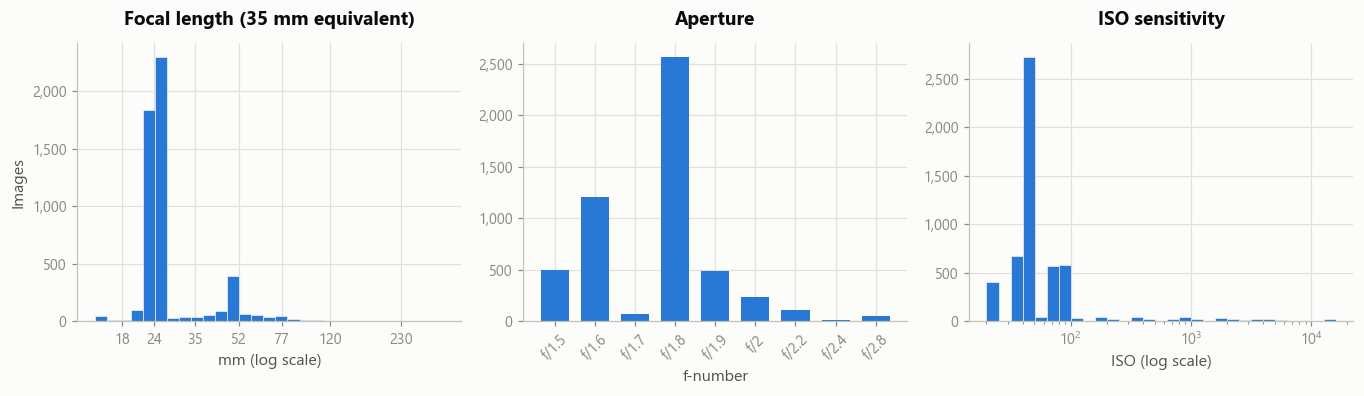

Focal length : median 25 mm equivalent
Aperture     : f/1.5 - f/2.8
ISO          : median 50, p95 400, max 16000
Exposure time: median 1/1332, longest 1/4
Flash fired  : 17 of 5,243 EXIF images (0.32%)


In [10]:
focal = readable["focal_length_35mm"].dropna()
focal = focal[focal > 0]
apertures = readable["f_number"].dropna()
aperture_counts = apertures[apertures > 0].round(1).value_counts().sort_index()
iso = readable["iso"].dropna()
iso = iso[iso > 0]  # a handful of devices write an invalid ISO/f-number of 0

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))

focal_bins = np.geomspace(focal.min(), focal.max(), 30)
axes[0].hist(focal, bins=focal_bins, color=plotstyle.ACCENT,
             edgecolor=plotstyle.SURFACE, linewidth=0.4)
axes[0].set_xscale("log")
focal_ticks = [13, 18, 24, 35, 52, 77, 120, 230]
axes[0].set_xticks([t for t in focal_ticks if focal.min() <= t <= focal.max()])
axes[0].get_xaxis().set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
axes[0].minorticks_off()
axes[0].set_title("Focal length (35 mm equivalent)")
axes[0].set_xlabel("mm (log scale)")
axes[0].set_ylabel("Images")

axes[1].bar([f"f/{v:g}" for v in aperture_counts.index], aperture_counts.values,
            color=plotstyle.ACCENT, width=0.7)
axes[1].set_title("Aperture")
axes[1].set_xlabel("f-number")
axes[1].tick_params(axis="x", rotation=45)

iso_bins = np.geomspace(iso.min(), iso.max(), 30)
axes[2].hist(iso, bins=iso_bins, color=plotstyle.ACCENT,
             edgecolor=plotstyle.SURFACE, linewidth=0.4)
axes[2].set_xscale("log")
axes[2].set_title("ISO sensitivity")
axes[2].set_xlabel("ISO (log scale)")

for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.tight_layout()
plotstyle.save_fig(fig, "fig06_optics_exposure")
plt.show()

exp = readable["exposure_time_s"].dropna()
exp = exp[exp > 0]
print(f"Focal length : median {focal.median():.0f} mm equivalent")
print(f"Aperture     : f/{aperture_counts.index.min():g} - f/{aperture_counts.index.max():g}")
print(f"ISO          : median {iso.median():.0f}, p95 {iso.quantile(0.95):.0f}, max {iso.max():.0f}")
print(f"Exposure time: median {inventory.exposure_fraction(exp.median())}, "
      f"longest {inventory.exposure_fraction(exp.max())}")
flash = readable["flash_fired"].dropna()
print(f"Flash fired  : {int(flash.sum()):,} of {len(flash):,} EXIF images ({flash.mean():.2%})")


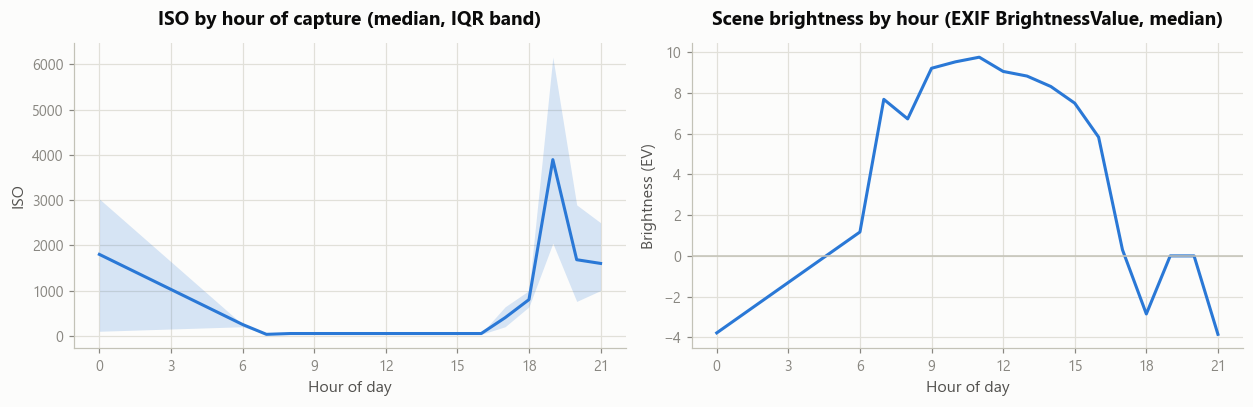

Captures between 07:00 and 17:59: 95.5% - the corpus is predominantly a daylight collection; low-light captures show the expected ISO rise.


In [11]:
timed = readable.dropna(subset=["datetime_original"]).copy()
timed["hour"] = timed["datetime_original"].dt.hour

by_hour = timed.groupby("hour").agg(
    iso_median=("iso", "median"),
    iso_q25=("iso", lambda s: s.quantile(0.25)),
    iso_q75=("iso", lambda s: s.quantile(0.75)),
    brightness=("brightness_ev", "median"),
    images=("filename", "size"),
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), sharex=True)
axes[0].fill_between(by_hour.index, by_hour["iso_q25"], by_hour["iso_q75"],
                     color=plotstyle.ACCENT, alpha=0.18, linewidth=0)
axes[0].plot(by_hour.index, by_hour["iso_median"], color=plotstyle.ACCENT, linewidth=2)
axes[0].set_title("ISO by hour of capture (median, IQR band)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("ISO")

axes[1].plot(by_hour.index, by_hour["brightness"], color=plotstyle.ACCENT, linewidth=2)
axes[1].axhline(0, color=plotstyle.BASELINE, linewidth=1)
axes[1].set_title("Scene brightness by hour (EXIF BrightnessValue, median)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Brightness (EV)")

for ax in axes:
    ax.set_xticks(range(0, 24, 3))
fig.tight_layout()
plotstyle.save_fig(fig, "fig07_lighting_by_hour")
plt.show()

daylight = timed["hour"].between(7, 17).mean()
print(f"Captures between 07:00 and 17:59: {daylight:.1%} - the corpus is predominantly "
      f"a daylight collection; low-light captures show the expected ISO rise.")


## 5. Geospatial analysis

GPS positions are read directly from EXIF. Points are assigned to their nearest locality
centre (approximate town centroids) and aggregated into the six statistical districts used
by Malta's National Statistics Office, giving a coarse but robust picture of regional
coverage. An interactive atlas with per-image markers is generated separately by
`Scripts/MTSD-Analysis/mtsd_mapper.py`.


In [12]:
gps = readable[readable["has_gps"]].copy()
in_malta = gps[gps["gps_latitude"].between(35.7, 36.2) &
               gps["gps_longitude"].between(14.1, 14.7)]
outliers = len(gps) - len(in_malta)

print(f"Images with GPS      : {len(gps):,} ({len(gps) / len(readable):.1%} of readable)")
print(f"Inside Malta bbox    : {len(in_malta):,}")
print(f"Outside Malta bbox   : {outliers:,}")
print(f"Latitude range       : {in_malta['gps_latitude'].min():.4f} - {in_malta['gps_latitude'].max():.4f}")
print(f"Longitude range      : {in_malta['gps_longitude'].min():.4f} - {in_malta['gps_longitude'].max():.4f}")
if "gps_altitude_m" in gps:
    alt = in_malta["gps_altitude_m"].dropna()
    print(f"Altitude (median/p95): {alt.median():.0f} m / {alt.quantile(0.95):.0f} m")


Images with GPS      : 4,228 (56.4% of readable)
Inside Malta bbox    : 4,228
Outside Malta bbox   : 0
Latitude range       : 35.8222 - 36.0714
Longitude range      : 14.2157 - 14.5455
Altitude (median/p95): 83 m / 148 m


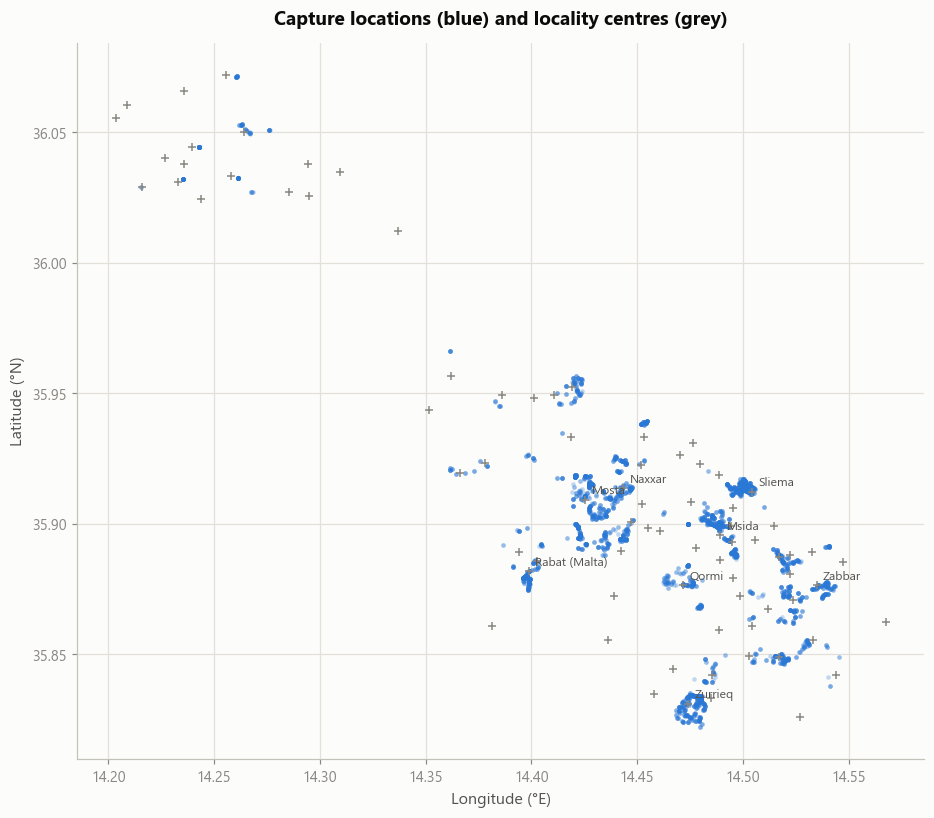

In [13]:
localised = geo.assign_localities(in_malta)

fig, ax = plt.subplots(figsize=(8.6, 7.6))
ax.scatter(localised["gps_longitude"], localised["gps_latitude"],
           s=9, color=plotstyle.ACCENT, alpha=0.28, linewidth=0)
centroids = geo.locality_frame()
ax.scatter(centroids["longitude"], centroids["latitude"], marker="+",
           s=26, color=plotstyle.INK_MUTED, linewidth=1)
for _, row in centroids.iterrows():
    if row["locality"] in localised["locality"].value_counts().head(8).index:
        ax.annotate(row["locality"], (row["longitude"], row["latitude"]),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=8, color=plotstyle.INK_SECONDARY)
ax.set_aspect(1 / np.cos(np.radians(35.9)))
ax.set_title("Capture locations (blue) and locality centres (grey)")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig08_gps_scatter")
plt.show()


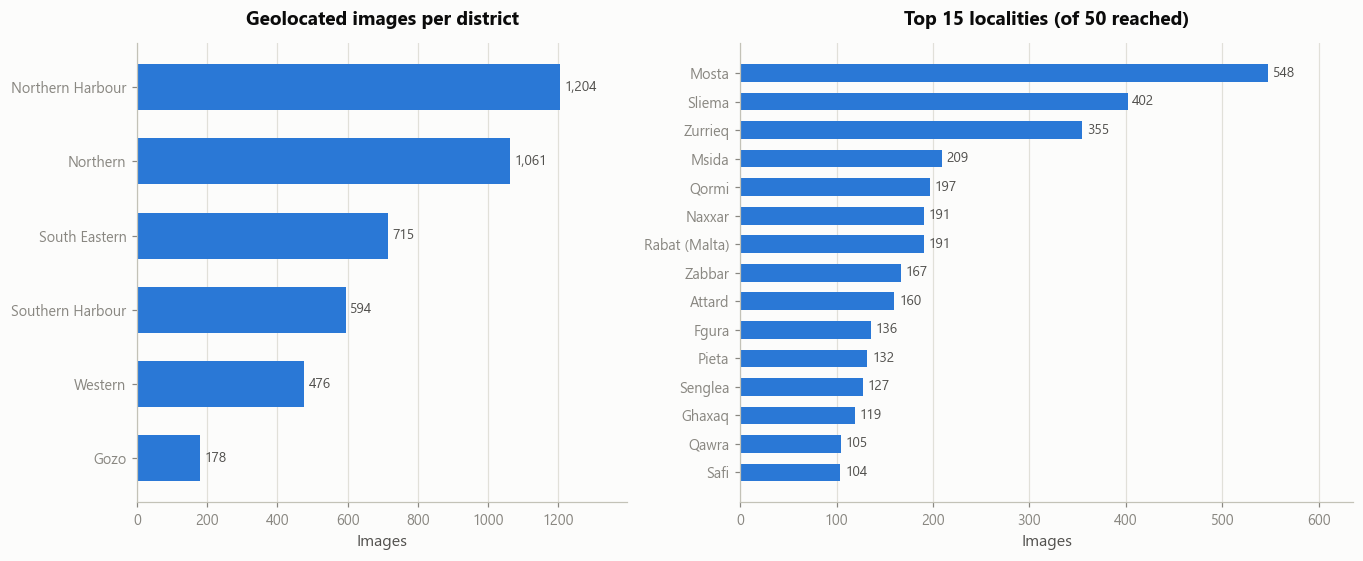

Localities reached: 50 of 79 reference centres
Gozo share        : 4.2% of geolocated captures


In [14]:
district_counts = localised["district"].value_counts()
locality_counts = localised["locality"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})

bars = axes[0].barh(district_counts.index[::-1], district_counts.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[0], bars)
plotstyle.style_h_barh(axes[0])
axes[0].set_title("Geolocated images per district")
axes[0].set_xlabel("Images")
axes[0].margins(x=0.16)

top_loc = locality_counts.head(15)
bars = axes[1].barh(top_loc.index[::-1], top_loc.values[::-1],
                    color=plotstyle.ACCENT, height=0.62)
plotstyle.bar_value_labels(axes[1], bars)
plotstyle.style_h_barh(axes[1])
axes[1].set_title(f"Top 15 localities (of {locality_counts.size} reached)")
axes[1].set_xlabel("Images")
axes[1].margins(x=0.16)

fig.tight_layout()
plotstyle.save_fig(fig, "fig09_regional_coverage")
plt.show()

locality_summary = (localised.groupby(["district", "locality"]).size()
                    .reset_index(name="images")
                    .sort_values("images", ascending=False))
locality_summary.to_csv(config.CSV_DIR / "locality_summary.csv", index=False)
gozo_share = district_counts.get("Gozo", 0) / district_counts.sum()
print(f"Localities reached: {locality_counts.size} of {len(centroids)} reference centres")
print(f"Gozo share        : {gozo_share:.1%} of geolocated captures")


### 5.1 Interactive density map

The embedded map below gives an interactive view of capture density (requires `folium`; the
cell degrades gracefully when the package is unavailable). For marker-level browsing with
image previews, use the standalone atlas produced by `mtsd_mapper.py`.


In [15]:
try:
    import folium
    from folium.plugins import HeatMap

    fmap = folium.Map(location=[35.94, 14.38], zoom_start=11, tiles="CartoDB positron",
                      attr="CartoDB")
    HeatMap(localised[["gps_latitude", "gps_longitude"]].values.tolist(),
            radius=11, blur=14, min_opacity=0.25).add_to(fmap)
    display(fmap)
except ImportError:
    print("folium is not installed - skipping the interactive map "
          "(pip install -r Requirements/requirements-general-tooling.txt).")


folium is not installed - skipping the interactive map (pip install -r Requirements/requirements-general-tooling.txt).


## 6. Temporal analysis

Capture timestamps (EXIF `DateTimeOriginal`) describe the collection campaign itself: its
duration, intensity, and weekly/diurnal rhythm. Note that images whose EXIF was stripped
(e.g. by messaging apps) carry no timestamp and are excluded from this section.


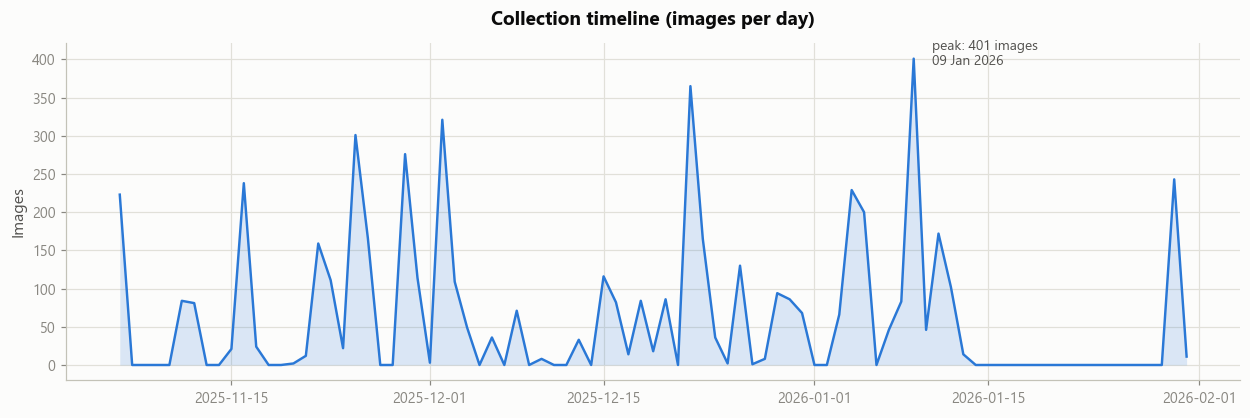

Campaign span : 87 days (06 Nov 2025 - 31 Jan 2026)
Active days   : 51 (59% of the span)  median on active days: 83 images


In [16]:
daily = timed.set_index("datetime_original").sort_index()
per_day = daily.resample("D").size()

fig, ax = plt.subplots(figsize=(11.5, 3.9))
ax.fill_between(per_day.index, per_day.values, color=plotstyle.ACCENT, alpha=0.16,
                linewidth=0)
ax.plot(per_day.index, per_day.values, color=plotstyle.ACCENT, linewidth=1.6)
peak_day = per_day.idxmax()
ax.annotate(f"peak: {per_day.max():,} images\n{peak_day:%d %b %Y}",
            xy=(peak_day, per_day.max()), xytext=(12, -4), textcoords="offset points",
            fontsize=9, color=plotstyle.INK_SECONDARY)
ax.set_title("Collection timeline (images per day)")
ax.set_xlabel("")
ax.set_ylabel("Images")
fig.tight_layout()
plotstyle.save_fig(fig, "fig10_capture_timeline")
plt.show()

active_days = int((per_day > 0).sum())
span_days = (per_day.index.max() - per_day.index.min()).days + 1
print(f"Campaign span : {span_days} days ({per_day.index.min():%d %b %Y} - "
      f"{per_day.index.max():%d %b %Y})")
print(f"Active days   : {active_days} ({active_days / span_days:.0%} of the span)  "
      f"median on active days: {per_day[per_day > 0].median():.0f} images")


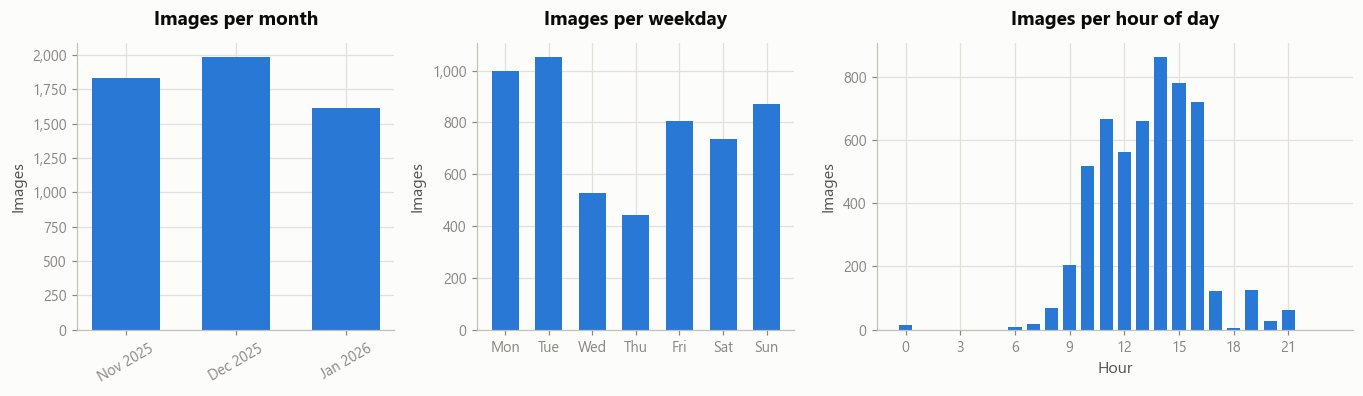

Weekend share: 29.6%   busiest hour: 14:00


In [17]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
timed["weekday"] = pd.Categorical(timed["datetime_original"].dt.strftime("%a"),
                                  categories=weekday_order, ordered=True)
timed["month"] = timed["datetime_original"].dt.strftime("%b %Y")
month_order = (timed.dropna(subset=["datetime_original"])
               .sort_values("datetime_original")["month"].unique())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7),
                         gridspec_kw={"width_ratios": [1, 1, 1.5]})

month_counts = timed["month"].value_counts().reindex(month_order)
axes[0].bar(month_counts.index, month_counts.values, color=plotstyle.ACCENT, width=0.62)
axes[0].set_title("Images per month")
axes[0].tick_params(axis="x", rotation=30)

weekday_counts = timed["weekday"].value_counts().reindex(weekday_order)
axes[1].bar(weekday_counts.index, weekday_counts.values, color=plotstyle.ACCENT, width=0.62)
axes[1].set_title("Images per weekday")

hour_counts = timed["hour"].value_counts().reindex(range(24), fill_value=0)
axes[2].bar(hour_counts.index, hour_counts.values, color=plotstyle.ACCENT, width=0.72)
axes[2].set_title("Images per hour of day")
axes[2].set_xlabel("Hour")
axes[2].set_xticks(range(0, 24, 3))

for ax in axes:
    ax.set_ylabel("Images")
    ax.yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.tight_layout()
plotstyle.save_fig(fig, "fig11_temporal_profiles")
plt.show()

weekend_share = timed["weekday"].isin(["Sat", "Sun"]).mean()
print(f"Weekend share: {weekend_share:.1%}   busiest hour: {hour_counts.idxmax()}:00")


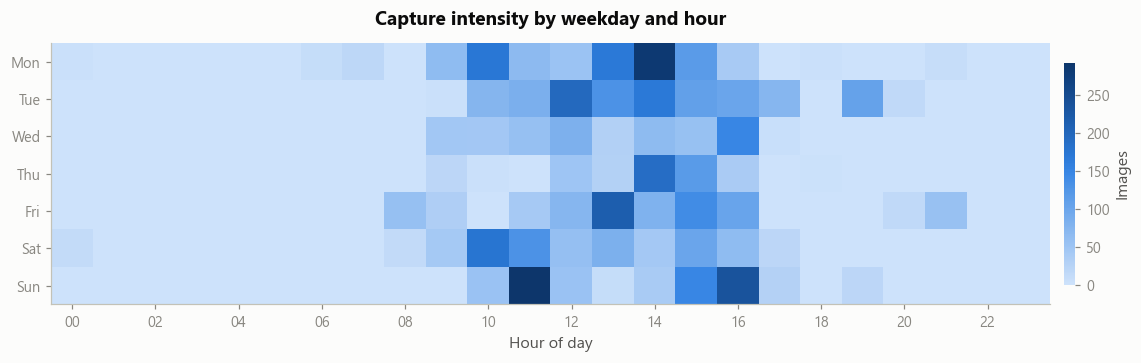

In [18]:
pivot = (timed.pivot_table(index="weekday", columns="hour", values="filename",
                           aggfunc="size", fill_value=0, observed=False)
         .reindex(weekday_order))
pivot = pivot.reindex(columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(11.5, 3.4))
mesh = ax.imshow(pivot.values, aspect="auto", cmap=plotstyle.BLUES_CMAP)
ax.set_yticks(range(7), weekday_order)
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_xlabel("Hour of day")
ax.set_title("Capture intensity by weekday and hour")
ax.grid(False)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.85, pad=0.012)
cbar.set_label("Images", color=plotstyle.INK_SECONDARY)
cbar.outline.set_visible(False)
fig.tight_layout()
plotstyle.save_fig(fig, "fig12_weekday_hour_heatmap")
plt.show()

temporal_summary = per_day.rename("images").reset_index()
temporal_summary.columns = ["date", "images"]
temporal_summary.to_csv(config.CSV_DIR / "temporal_summary.csv", index=False)


## 7. Annotation analysis

All statistics in this section derive **exclusively from the QA-verified COCO exports**
(`QA-GRP*.json`) — the raw annotator files are never consulted. Every bounding box carries
four auxiliary attributes assigned during annotation: *view angle*, *mounting*, *condition*,
and *sign shape*.

### 7.1 Annotation inventory


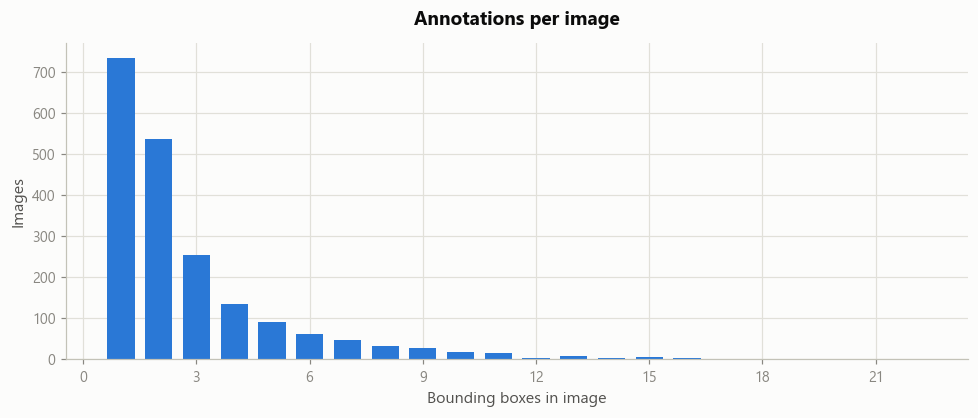

Annotated images      : 1,971
Images with no boxes  : 0
Boxes per image       : mean 2.77, median 2, p95 8, max 22
Single-box images     : 37.1%


In [19]:
per_image = qa_anns.groupby("image_uid").size()
empty_images = len(qa_images) - per_image.index.nunique()

fig, ax = plt.subplots(figsize=(9, 3.9))
counts = per_image.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=plotstyle.ACCENT, width=0.72)
ax.set_title("Annotations per image")
ax.set_xlabel("Bounding boxes in image")
ax.set_ylabel("Images")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.tight_layout()
plotstyle.save_fig(fig, "fig13_annotations_per_image")
plt.show()

print(f"Annotated images      : {per_image.index.nunique():,}")
print(f"Images with no boxes  : {empty_images:,}")
print(f"Boxes per image       : mean {per_image.mean():.2f}, median {per_image.median():.0f}, "
      f"p95 {per_image.quantile(0.95):.0f}, max {per_image.max()}")
print(f"Single-box images     : {(per_image == 1).mean():.1%}")


### 7.2 Class distribution and imbalance

Class frequencies follow the long-tailed distribution typical of street-level object
datasets. The two *Unknown* classes (`Back-Unknown`, `Other-Unknown`) capture sign backs and
unclassifiable plates; the remaining classes are concrete Maltese sign types. Imbalance is
quantified with the maximum/minimum ratio, the Gini coefficient over class frequencies, and
the share of instances covered by the head of the distribution.


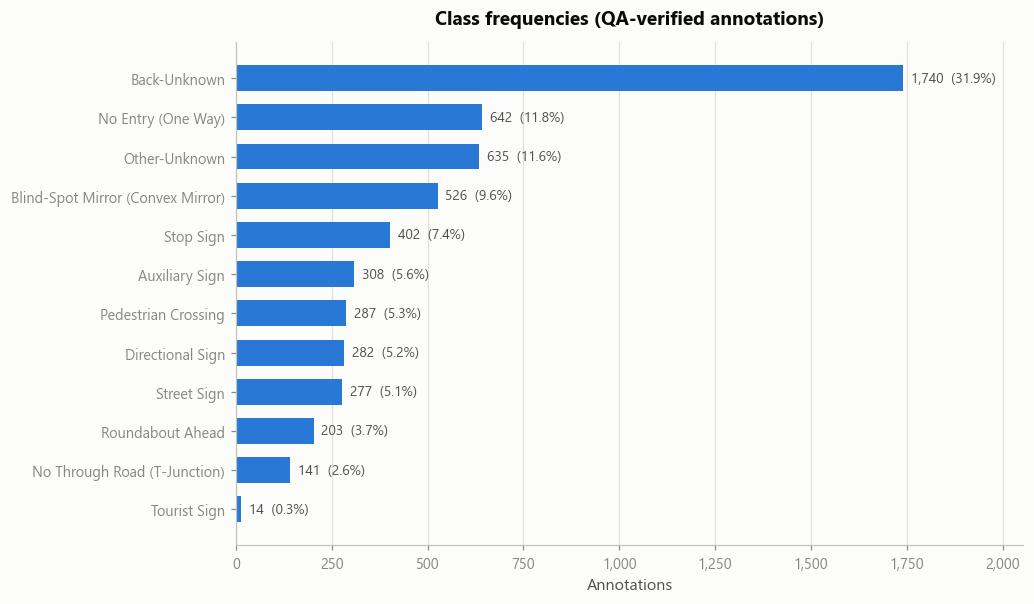

In [20]:
class_counts = qa_anns["category_name"].value_counts()
share = class_counts / class_counts.sum()

fig, ax = plt.subplots(figsize=(9.5, 5.6))
bars = ax.barh(class_counts.index[::-1], class_counts.values[::-1],
               color=plotstyle.ACCENT, height=0.66)
for bar, (name, count) in zip(ax.patches, list(class_counts.items())[::-1]):
    ax.annotate(f"{count:,}  ({share[name]:.1%})",
                (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=plotstyle.INK_SECONDARY)
plotstyle.style_h_barh(ax)
ax.set_title("Class frequencies (QA-verified annotations)")
ax.set_xlabel("Annotations")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.margins(x=0.18)
fig.tight_layout()
plotstyle.save_fig(fig, "fig14_class_frequencies")
plt.show()

freq_table = pd.DataFrame({"annotations": class_counts,
                           "share_pct": (share * 100).round(2)})
freq_table.to_csv(config.CSV_DIR / "class_frequencies.csv")


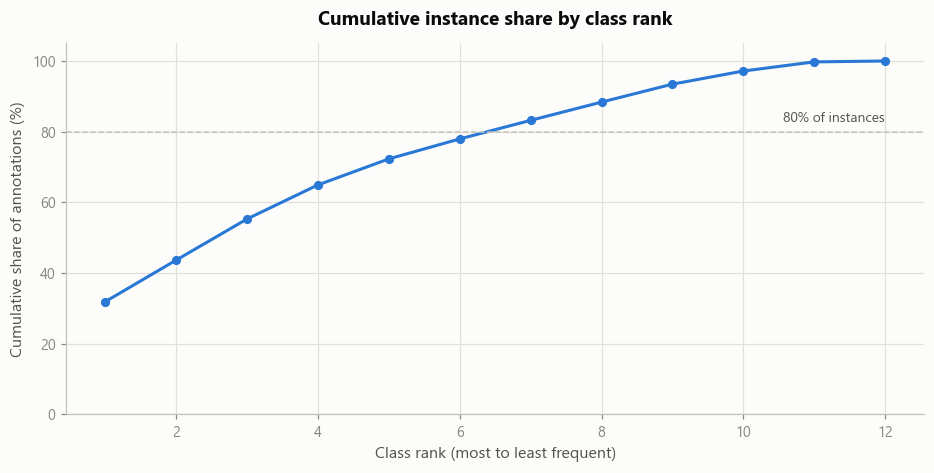

- **Imbalance ratio** (most/least frequent): **124 : 1**
- **Gini coefficient** over class frequencies: **0.43**
- The **top class** alone holds **31.9%** of instances; the top three hold 55.3%
- **7 of 12 classes** account for 80% of all instances

In [21]:
imbalance = coco.class_imbalance_metrics(qa_anns)
cumulative = share.cumsum().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, color=plotstyle.ACCENT,
        linewidth=2, marker="o", markersize=5)
ax.axhline(80, color=plotstyle.BASELINE, linewidth=1, linestyle="--")
ax.annotate("80% of instances", xy=(len(cumulative), 80), xytext=(0, 6),
            textcoords="offset points", ha="right", fontsize=9,
            color=plotstyle.INK_SECONDARY)
ax.set_title("Cumulative instance share by class rank")
ax.set_xlabel("Class rank (most to least frequent)")
ax.set_ylabel("Cumulative share of annotations (%)")
ax.set_ylim(0, 105)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.tight_layout()
plotstyle.save_fig(fig, "fig15_class_longtail")
plt.show()

display(Markdown(
    f"- **Imbalance ratio** (most/least frequent): **{imbalance['imbalance_ratio']:.0f} : 1**\n"
    f"- **Gini coefficient** over class frequencies: **{imbalance['gini_coefficient']:.2f}**\n"
    f"- The **top class** alone holds **{imbalance['top1_share_pct']:.1f}%** of instances; "
    f"the top three hold {imbalance['top3_share_pct']:.1f}%\n"
    f"- **{imbalance['classes_for_80pct']} of {imbalance['num_classes']} classes** "
    f"account for 80% of all instances"
))


### 7.3 Bounding-box geometry

Box geometry is analysed in image-relative coordinates so mixed resolutions do not distort
the picture. The COCO small/medium/large convention (thresholds at 32² and 96² absolute
pixels) is also reported, since it drives evaluation protocols such as AP_S/AP_M/AP_L.


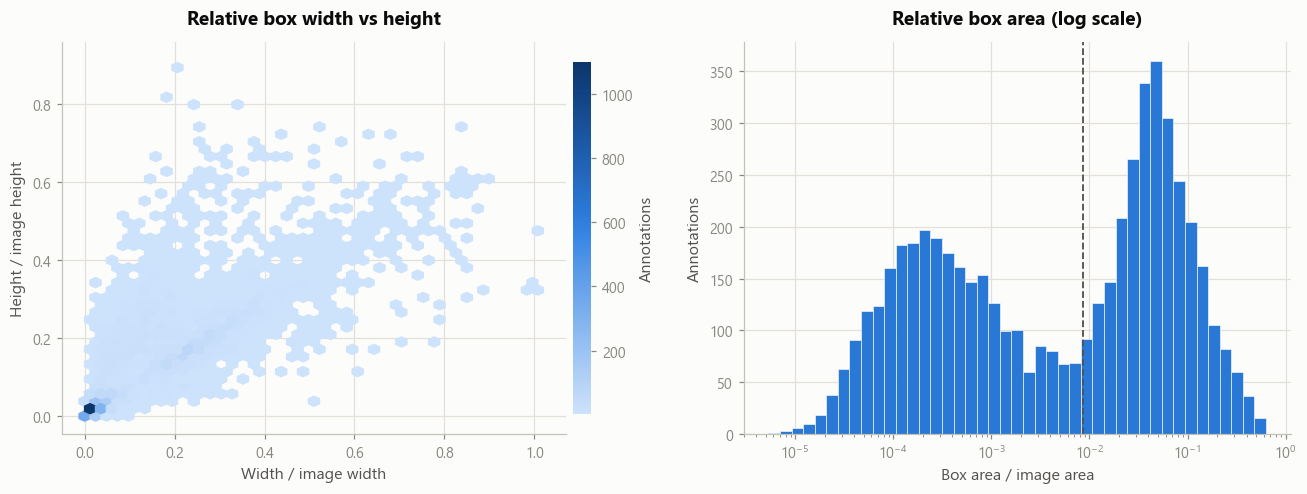

Median relative area : 0.8647% of the image
Median box (px)      : 216 x 397
Box aspect (w/h)     : median 0.89, IQR 0.52-1.05


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})

hexes = axes[0].hexbin(qa_anns["rel_width"], qa_anns["rel_height"], gridsize=42,
                       cmap=plotstyle.BLUES_CMAP, mincnt=1,
                       extent=(0, qa_anns["rel_width"].max() * 1.02,
                               0, qa_anns["rel_height"].max() * 1.02))
axes[0].set_title("Relative box width vs height")
axes[0].set_xlabel("Width / image width")
axes[0].set_ylabel("Height / image height")
cbar = fig.colorbar(hexes, ax=axes[0], shrink=0.9, pad=0.012)
cbar.set_label("Annotations", color=plotstyle.INK_SECONDARY)
cbar.outline.set_visible(False)

positive_area = qa_anns.loc[qa_anns["rel_area"] > 0, "rel_area"]
area_bins = np.geomspace(positive_area.min(), positive_area.max(), 44)
axes[1].hist(positive_area, bins=area_bins, color=plotstyle.ACCENT,
             edgecolor=plotstyle.SURFACE, linewidth=0.4)
axes[1].set_xscale("log")
axes[1].axvline(qa_anns["rel_area"].median(), color=plotstyle.INK_SECONDARY,
                linewidth=1.2, linestyle="--")
axes[1].set_title("Relative box area (log scale)")
axes[1].set_xlabel("Box area / image area")
axes[1].set_ylabel("Annotations")

fig.tight_layout()
plotstyle.save_fig(fig, "fig16_bbox_geometry")
plt.show()

print(f"Median relative area : {qa_anns['rel_area'].median():.4%} of the image")
print(f"Median box (px)      : {qa_anns['bbox_w'].median():.0f} x {qa_anns['bbox_h'].median():.0f}")
print(f"Box aspect (w/h)     : median {qa_anns['bbox_aspect'].median():.2f}, "
      f"IQR {qa_anns['bbox_aspect'].quantile(0.25):.2f}-{qa_anns['bbox_aspect'].quantile(0.75):.2f}")


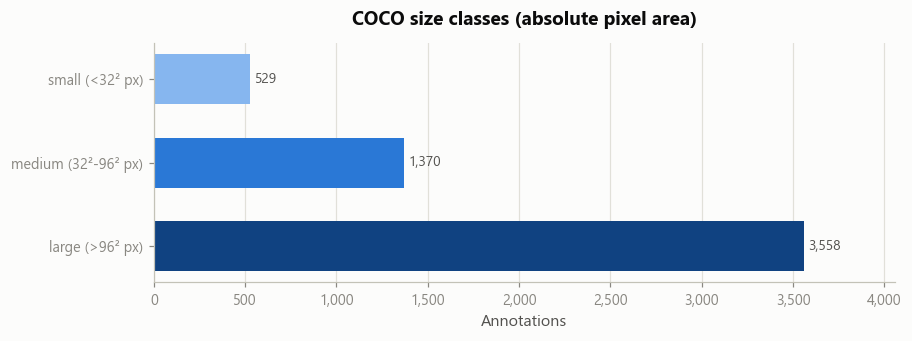

Small-object share (COCO <32² px): 9.7%


In [23]:
# Ordered size classes wear an ordinal one-hue ramp (light -> dark = small -> large).
ORDINAL_3 = ["#86b6ef", "#2a78d6", "#104281"]
size_counts = qa_anns["size_class"].value_counts().reindex(
    ["small (<32² px)", "medium (32²-96² px)", "large (>96² px)"])

fig, ax = plt.subplots(figsize=(8.4, 3.2))
bars = ax.barh(size_counts.index[::-1], size_counts.values[::-1],
               color=ORDINAL_3[::-1], height=0.6)
plotstyle.bar_value_labels(ax, bars)
plotstyle.style_h_barh(ax)
ax.set_title("COCO size classes (absolute pixel area)")
ax.set_xlabel("Annotations")
ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
ax.margins(x=0.14)
fig.tight_layout()
plotstyle.save_fig(fig, "fig17_coco_size_classes")
plt.show()

print(f"Small-object share (COCO <32² px): {size_counts.iloc[0] / size_counts.sum():.1%}")


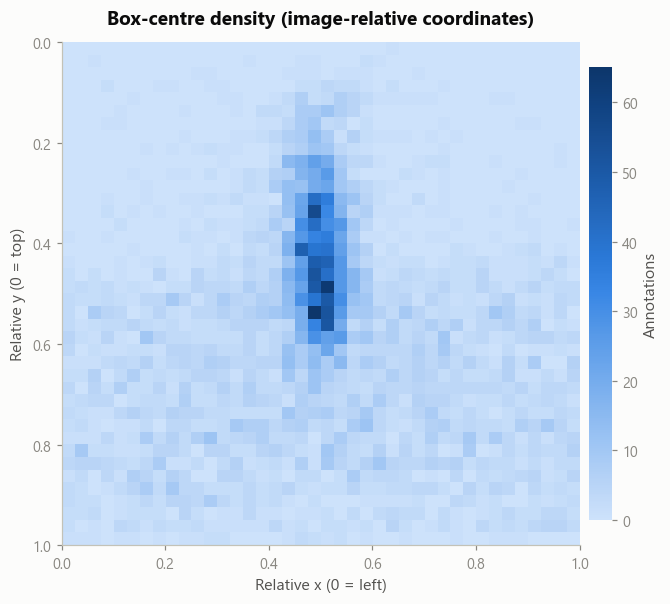

Box centres in the central third of the frame: 41.4% - a strong centring prior, consistent with deliberate, sign-focused capture rather than dashcam footage.


In [24]:
heat, xedges, yedges = np.histogram2d(qa_anns["rel_cx"], qa_anns["rel_cy"],
                                      bins=40, range=[[0, 1], [0, 1]])

fig, ax = plt.subplots(figsize=(6.4, 5.6))
mesh = ax.imshow(heat.T, origin="upper", extent=(0, 1, 1, 0),
                 cmap=plotstyle.BLUES_CMAP, aspect="auto")
ax.set_title("Box-centre density (image-relative coordinates)")
ax.set_xlabel("Relative x (0 = left)")
ax.set_ylabel("Relative y (0 = top)")
ax.grid(False)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.9, pad=0.015)
cbar.set_label("Annotations", color=plotstyle.INK_SECONDARY)
cbar.outline.set_visible(False)
fig.tight_layout()
plotstyle.save_fig(fig, "fig18_box_centre_density")
plt.show()

central = ((qa_anns["rel_cx"].between(1/3, 2/3)) & (qa_anns["rel_cy"].between(1/3, 2/3))).mean()
print(f"Box centres in the central third of the frame: {central:.1%} - a strong centring "
      f"prior, consistent with deliberate, sign-focused capture rather than dashcam footage.")


### 7.4 Class co-occurrence

The matrix counts images in which two classes appear together (diagonal = images containing
the class at all). Co-occurrence structure matters for sampling strategy: classes that only
appear alongside dominant ones cannot be isolated by naive image-level resampling.


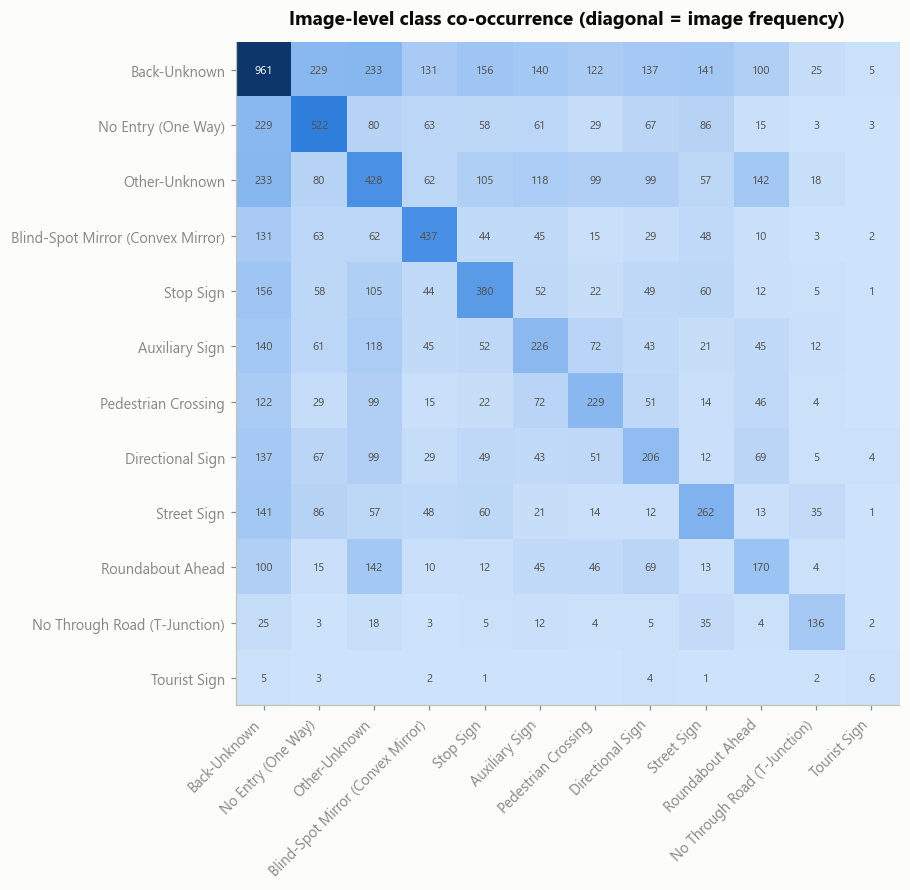

In [25]:
presence = (qa_anns.assign(present=1)
            .pivot_table(index="image_uid", columns="category_name",
                         values="present", aggfunc="max", fill_value=0))
order = class_counts.index.tolist()
present_ordered = presence[order]
cooc = present_ordered.T @ present_ordered

fig, ax = plt.subplots(figsize=(9.6, 8.2))
mesh = ax.imshow(cooc.values, cmap=plotstyle.BLUES_CMAP)
ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
ax.set_yticks(range(len(order)), order)
ax.grid(False)
threshold = cooc.values.max() * 0.55
for i in range(len(order)):
    for j in range(len(order)):
        value = int(cooc.values[i, j])
        if value:
            ax.text(j, i, f"{value:,}", ha="center", va="center", fontsize=7.5,
                    color=plotstyle.SURFACE if value > threshold else plotstyle.INK_SECONDARY)
ax.set_title("Image-level class co-occurrence (diagonal = image frequency)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig19_class_cooccurrence")
plt.show()

cooc.to_csv(config.CSV_DIR / "class_cooccurrence.csv")


### 7.5 Auxiliary attributes

Every QA-verified box carries four auxiliary attributes. These enable stratified evaluation
(e.g. detection quality on weathered vs pristine signs) and provide a physical-condition
census of Maltese signage as a by-product of the dataset.


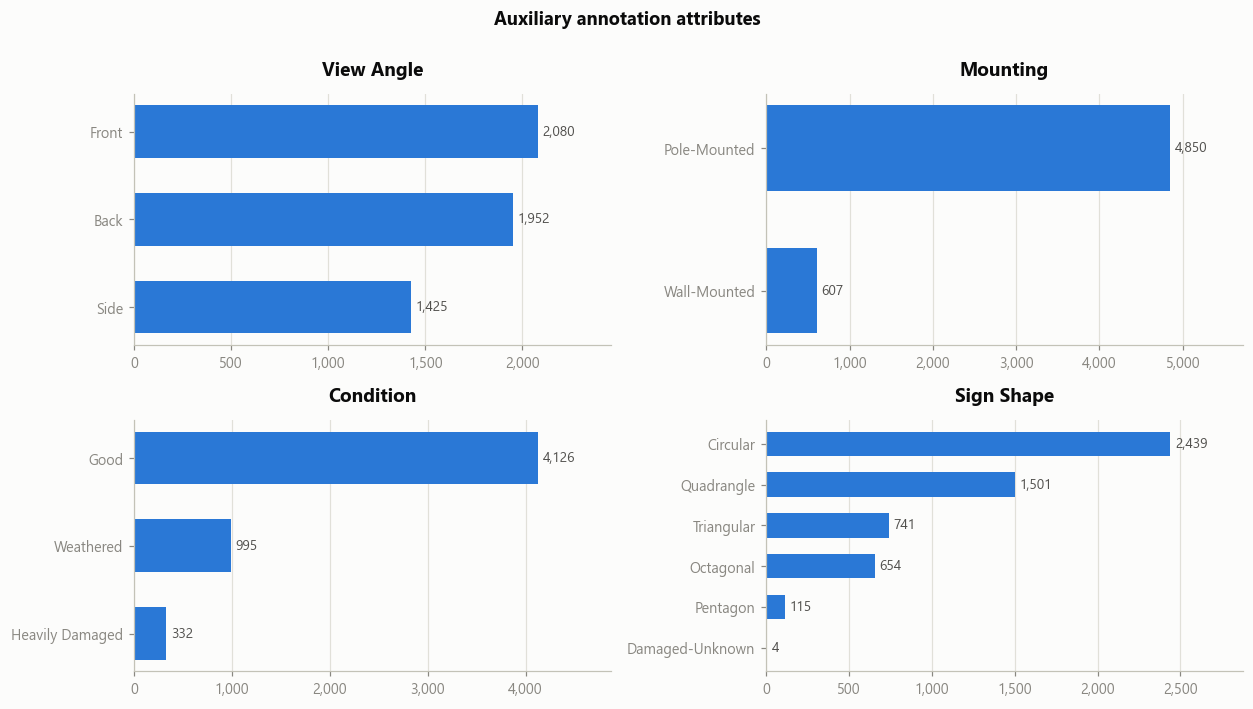

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.4))
for ax, column in zip(axes.flat, ["view_angle", "mounting", "condition", "sign_shape"]):
    counts = qa_anns[column].value_counts()
    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=plotstyle.ACCENT, height=0.6)
    plotstyle.bar_value_labels(ax, bars)
    plotstyle.style_h_barh(ax)
    ax.set_title(column.replace("_", " ").title())
    ax.margins(x=0.18)
    ax.xaxis.set_major_formatter(FuncFormatter(plotstyle.thousands))
fig.suptitle("Auxiliary annotation attributes", fontweight="bold", y=1.0)
fig.tight_layout()
plotstyle.save_fig(fig, "fig20_auxiliary_attributes")
plt.show()

attr_summary = pd.concat({column: qa_anns[column].value_counts()
                          for column in coco.ATTRIBUTE_KEYS[:4]}, names=["attribute", "value"])
attr_summary.rename("annotations").to_csv(config.CSV_DIR / "attribute_summary.csv")


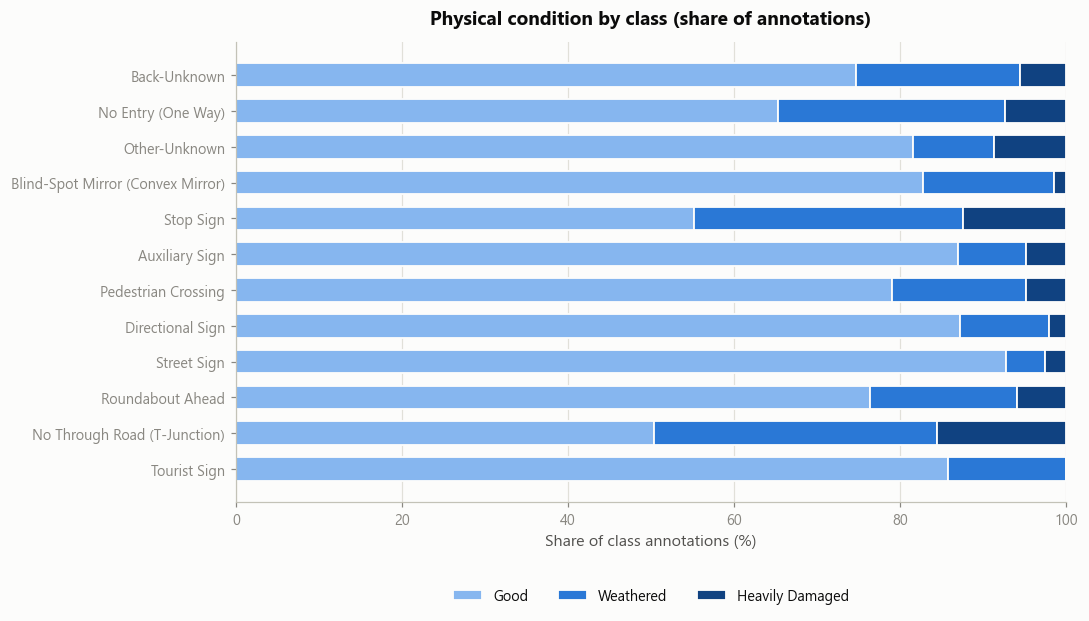

Signs not in good condition: 24.4% of all annotations


In [27]:
# Condition severity is ordered -> ordinal one-hue ramp (light = good, dark = damaged).
condition_order = ["Good", "Weathered", "Heavily Damaged"]
by_class = (qa_anns.dropna(subset=["condition"])
            .pivot_table(index="category_name", columns="condition",
                         values="annotation_uid", aggfunc="size", fill_value=0)
            .reindex(columns=condition_order)
            .reindex(class_counts.index))
shares = by_class.div(by_class.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 5.8))
left = np.zeros(len(shares))
for column, colour in zip(condition_order, ORDINAL_3):
    values = shares[column].values * 100
    ax.barh(shares.index[::-1], values[::-1], left=left[::-1], color=colour,
            height=0.66, label=column, edgecolor=plotstyle.SURFACE, linewidth=1.2)
    left += values
ax.set_xlim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncols=3, frameon=False)
plotstyle.style_h_barh(ax)
ax.set_title("Physical condition by class (share of annotations)")
ax.set_xlabel("Share of class annotations (%)")
fig.tight_layout()
plotstyle.save_fig(fig, "fig21_condition_by_class")
plt.show()

weathered_share = (qa_anns["condition"] != "Good").mean()
print(f"Signs not in good condition: {weathered_share:.1%} of all annotations")


### 7.6 Annotation quality and consistency checks

Automated validation of the QA exports: degenerate or out-of-bounds geometry, duplicated
boxes, orphaned records, unannotated images, missing attributes, and two-way reconciliation
between the QA files and the images actually on disk. Non-empty findings are exported to
`annotation_qc_*.csv` for follow-up.


In [28]:
qc = coco.annotation_quality_report(qa_images, qa_anns, inventory=inv)

qc_summary = pd.DataFrame(
    [(name.replace("_", " "), len(frame)) for name, frame in qc.items()],
    columns=["Check", "Findings"],
)
display(qc_summary.style.hide(axis="index"))

for name, frame in qc.items():
    if len(frame):
        frame.to_csv(config.CSV_DIR / f"annotation_qc_{name}.csv", index=False)
        print(f"\n--- {name} ({len(frame)} findings, first 5) " + "-" * 30)
        display(frame.head(5))


Check,Findings
degenerate boxes,0
out of bounds boxes,0
suspiciously small boxes,0
duplicate boxes,35
orphan annotations,0
images without annotations,0
missing attributes,7
qa entries missing on disk,0
disk images missing in qa,0



--- duplicate_boxes (35 findings, first 5) ------------------------------


,annotation_uid,image_uid,category_name,bbox_x,bbox_y,bbox_w,bbox_h,image_width,image_height
1052,1053,382,Stop Sign,325.25,858.76,2153.35,2108.79,3072,4096
1053,1054,382,Stop Sign,325.25,858.76,2153.35,2108.79,3072,4096
1055,1056,383,Back-Unknown,871.89,3175.43,48.69,53.99,3024,4032
1056,1057,383,Directional Sign,1012.86,3337.06,77.46,92.47,3024,4032
1057,1058,383,Directional Sign,1012.86,3337.06,77.46,92.47,3024,4032



--- missing_attributes (7 findings, first 5) ------------------------------


,annotation_uid,image_uid,category_name,view_angle,mounting,condition,sign_shape
281,282,123,Street Sign,Front,Pole-Mounted,Good,None
521,522,205,Blind-Spot Mirror (Convex Mirror),Back,Pole-Mounted,Good,None
657,658,253,Pedestrian Crossing,Front,Pole-Mounted,None,Triangular
943,944,354,Back-Unknown,Back,Pole-Mounted,Good,None
979,980,363,Back-Unknown,Back,Pole-Mounted,None,Triangular


### 7.7 Duplicate image detection

Perceptual difference hashes (dHash, 64-bit) flag visually identical or near-identical
images across the whole corpus — including re-exports whose bytes differ (recompression,
metadata stripping) but whose content is the same. Pairs at Hamming distance 0 are
byte-level or recompression duplicates; small non-zero distances usually indicate edited
variants of the same capture.


In [29]:
near_dupes = inventory.find_near_duplicates(inv, max_distance=NEAR_DUPLICATE_BITS)
exact = near_dupes[near_dupes["hamming_distance"] == 0]

print(f"Near-duplicate pairs (<= {NEAR_DUPLICATE_BITS} bits): {len(near_dupes)}")
print(f"  of which visually exact (0 bits)   : {len(exact)}")
if len(near_dupes):
    near_dupes.to_csv(config.CSV_DIR / "near_duplicate_images.csv", index=False)
    display(near_dupes.head(12))


Near-duplicate pairs (<= 2 bits): 12
  of which visually exact (0 bits)   : 11


,file_a,file_b,group_a,group_b,hamming_distance,same_file_size
0,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
1,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
2,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
3,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
4,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
5,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
6,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
7,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
8,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False
9,Datasets/GRP-10/merged_images/WhatsApp Image 2...,Datasets/GRP-10/merged_images/WhatsApp Image 2...,GRP-10,GRP-10,0,False


## 8. Dataset summary and discussion

The table below consolidates the headline statistics computed throughout the notebook; the
narrative that follows interprets them for the dissertation.


In [30]:
key_stats = pd.DataFrame(
    [
        ("Images on disk", f"{len(inv):,}"),
        ("Total volume", f"{inv['file_size_bytes'].sum() / 1024**3:,.2f} GiB"),
        ("Unreadable images", f"{int(inv['is_corrupted'].sum()):,}"),
        ("EXIF coverage", f"{readable['has_exif'].mean():.1%}"),
        ("GPS coverage", f"{readable['has_gps'].mean():.1%}"),
        ("Median resolution", f"{readable['width'].median():.0f}×{readable['height'].median():.0f} px"),
        ("Median megapixels", f"{readable['megapixels'].median():.1f} MP"),
        ("Portrait orientation", f"{(readable['orientation'] == 'portrait').mean():.1%}"),
        ("Device manufacturers", f"{readable['make_norm'].nunique()}"),
        ("Distinct camera models", f"{readable['camera_model'].nunique()}"),
        ("Capture window", capture_window),
        ("Localities reached", f"{locality_summary['locality'].nunique()}"),
        ("QA-verified images", f"{len(qa_images):,}"),
        ("QA-verified annotations", f"{len(qa_anns):,}"),
        ("Annotation classes", f"{len(qa_cats)}"),
        ("Boxes per image (mean)", f"{per_image.mean():.2f}"),
        ("Class imbalance ratio", f"{imbalance['imbalance_ratio']:.0f} : 1"),
        ("Gini coefficient (classes)", f"{imbalance['gini_coefficient']:.2f}"),
        ("Small objects (COCO)", f"{(qa_anns['size_class'].cat.codes == 0).mean():.1%}"),
        ("Median relative box area", f"{qa_anns['rel_area'].median():.3%}"),
        ("Signs not in good condition", f"{weathered_share:.1%}"),
        ("Near-duplicate pairs", f"{len(near_dupes)}"),
    ],
    columns=["Statistic", "Value"],
)
key_stats.to_csv(config.CSV_DIR / "dataset_key_statistics.csv", index=False)
key_stats.style.hide(axis="index")


Statistic,Value
Images on disk,"7,492"
Total volume,20.76 GiB
Unreadable images,0
EXIF coverage,76.9%
GPS coverage,56.4%
Median resolution,3024×4032 px
Median megapixels,12.2 MP
Portrait orientation,97.3%
Device manufacturers,5
Distinct camera models,34


In [31]:
display(Markdown(f"""
### Strengths

- **Verified ground truth.** Every annotation has passed a manual QA pass; the automated
  consistency checks in §7.6 found no degenerate or out-of-bounds geometry, and QA files
  reconcile exactly with the images on disk.
- **Rich metadata.** {readable['has_exif'].mean():.0%} of images carry full EXIF and
  {readable['has_gps'].mean():.0%} carry GPS, enabling the spatial and temporal analyses
  above and supporting stratified evaluation by device, place, and time.
- **Device diversity.** {readable['camera_model'].nunique()} camera models from
  {readable['make_norm'].nunique()} manufacturers guard against single-sensor overfitting.
- **Auxiliary attributes.** Per-box view angle, mounting, condition, and shape allow
  fine-grained error analysis unusual for datasets of this size.
- **High resolution.** A median of {readable['megapixels'].median():.0f} MP preserves the
  fine detail of distant signs, which matters given the small-object share.

### Limitations and potential biases

- **Class imbalance.** A long-tailed distribution ({imbalance['imbalance_ratio']:.0f}:1
  head-to-tail; the top class alone holds {imbalance['top1_share_pct']:.0f}% of instances)
  will require re-weighting, resampling, or loss shaping during training.
- **Viewpoint bias.** Captures are pedestrian, deliberately framed
  ({(readable['orientation'] == 'portrait').mean():.0%} portrait; box centres cluster in the
  central third of the frame), so models trained on MTSD may transfer imperfectly to
  vehicle-mounted, landscape-framed cameras.
- **Temporal concentration.** The campaign spans {span_days} days in a single season,
  limiting seasonal and rare-weather variation; {timed['hour'].between(7, 17).mean():.0%}
  of captures are daytime.
- **Geographic concentration.** Coverage follows the collectors' routes; several localities
  dominate while others are sparsely represented (§5), so spatially stratified splits are
  advisable.
- **Metadata gaps.** {1 - readable['has_exif'].mean():.0%} of images lack EXIF (mostly
  messaging-app re-exports), and the near-duplicate scan flagged {len(near_dupes)} pairs
  that should be de-duplicated or forced into the same split to avoid leakage.

### Implications for model development

1. Evaluation should report per-class metrics and COCO size-stratified AP, given the
   imbalance and the {(qa_anns['size_class'].cat.codes == 0).mean():.0%} small-object share.
2. Train/validation/test splits should be grouped by capture location and near-duplicate
   cluster to prevent spatial and duplicate leakage.
3. The condition attribute supports robustness studies on weathered signage
   ({weathered_share:.0%} of instances) — a distinctive contribution of this dataset.
"""))



### Strengths

- **Verified ground truth.** Every annotation has passed a manual QA pass; the automated
  consistency checks in §7.6 found no degenerate or out-of-bounds geometry, and QA files
  reconcile exactly with the images on disk.
- **Rich metadata.** 77% of images carry full EXIF and
  56% carry GPS, enabling the spatial and temporal analyses
  above and supporting stratified evaluation by device, place, and time.
- **Device diversity.** 34 camera models from
  5 manufacturers guard against single-sensor overfitting.
- **Auxiliary attributes.** Per-box view angle, mounting, condition, and shape allow
  fine-grained error analysis unusual for datasets of this size.
- **High resolution.** A median of 12 MP preserves the
  fine detail of distant signs, which matters given the small-object share.

### Limitations and potential biases

- **Class imbalance.** A long-tailed distribution (124:1
  head-to-tail; the top class alone holds 32% of instances)
  will require re-weighting, resampling, or loss shaping during training.
- **Viewpoint bias.** Captures are pedestrian, deliberately framed
  (97% portrait; box centres cluster in the
  central third of the frame), so models trained on MTSD may transfer imperfectly to
  vehicle-mounted, landscape-framed cameras.
- **Temporal concentration.** The campaign spans 87 days in a single season,
  limiting seasonal and rare-weather variation; 96%
  of captures are daytime.
- **Geographic concentration.** Coverage follows the collectors' routes; several localities
  dominate while others are sparsely represented (§5), so spatially stratified splits are
  advisable.
- **Metadata gaps.** 23% of images lack EXIF (mostly
  messaging-app re-exports), and the near-duplicate scan flagged 12 pairs
  that should be de-duplicated or forced into the same split to avoid leakage.

### Implications for model development

1. Evaluation should report per-class metrics and COCO size-stratified AP, given the
   imbalance and the 10% small-object share.
2. Train/validation/test splits should be grouped by capture location and near-duplicate
   cluster to prevent spatial and duplicate leakage.
3. The condition attribute supports robustness studies on weathered signage
   (24% of instances) — a distinctive contribution of this dataset.


## 9. Exported artefacts

Every figure and table generated by this notebook, for direct inclusion in the dissertation.


In [32]:
artefacts = []
for folder, kind in ((config.FIGURES_DIR, "figure"), (config.CSV_DIR, "table")):
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artefacts.append({"kind": kind, "file": path.name,
                              "size_kb": round(path.stat().st_size / 1024, 1)})
artefact_frame = pd.DataFrame(artefacts)
print(f"{len(artefact_frame)} artefacts in {config.EDA_DIR}")
artefact_frame


51 artefacts in E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MTSD-EDA


,kind,file,size_kb
0,figure,fig01_formats_and_file_size.png,99.3
1,figure,fig02_resolution_landscape.png,227.3
2,figure,fig03_geometry_profile.png,123.7
3,figure,fig04_manufacturers.png,76.4
4,figure,fig05_camera_models.png,148.8
5,figure,fig06_optics_exposure.png,139.0
6,figure,fig07_lighting_by_hour.png,189.9
7,figure,fig08_gps_scatter.png,232.1
8,figure,fig09_regional_coverage.png,185.6
9,figure,fig10_capture_timeline.png,216.1
